In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv('steam_final.csv')
print(df.columns)
df.head()

Index(['Unnamed: 0.1', 'appid', 'name', 'release_date', 'english', 'developer',
       'publisher', 'platforms', 'required_age', 'categories',
       ...
       'Valve Anti-Cheat enabled_cat', 'Unnamed: 0', 'cleaned',
       'processor_Ghz', 'RAM_mb', 'GPU_mb', 'internet_required', 'storage_mb',
       'cpu_source', 'tier'],
      dtype='str', length=510)


,Unnamed: 0.1,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,...,Valve Anti-Cheat enabled_cat,Unnamed: 0,cleaned,processor_Ghz,RAM_mb,GPU_mb,internet_required,storage_mb,cpu_source,tier
0,0,10,Counter-Strike,2000-11-01,1,Valve,Valve,"['windows', 'mac', 'linux']",0,"['Multi-player', 'Online Multi-Player', 'Local...",...,1,0,"Minimum: 500 mhz processor, 96mb ram, 16mb vi...",0.5,96.0,16.0,1,NaN,measured,Low
1,6,30,Day of Defeat,2003-05-01,1,Valve,Valve,"['windows', 'mac', 'linux']",0,"['Multi-player', 'Valve Anti-Cheat enabled']",...,1,0,"Minimum: 500 mhz processor, 96mb ram, 16mb vi...",0.5,96.0,16.0,1,NaN,measured,Low
2,12,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,"['windows', 'mac', 'linux']",0,"['Single-player', 'Multi-player', 'Valve Anti-...",...,1,0,"Minimum: 500 mhz processor, 96mb ram, 16mb vi...",0.5,96.0,16.0,1,NaN,measured,Low
3,18,70,Half-Life,1998-11-08,1,Valve,Valve,"['windows', 'mac', 'linux']",0,"['Single-player', 'Multi-player', 'Online Mult...",...,1,0,"Minimum: 500 mhz processor, 96mb ram, 16mb vi...",0.5,96.0,16.0,1,NaN,measured,Low
4,24,80,Counter-Strike: Condition Zero,2004-03-01,1,Valve,Valve,"['windows', 'mac', 'linux']",0,"['Single-player', 'Multi-player', 'Valve Anti-...",...,1,0,"Minimum: 500 mhz processor, 96mb ram, 16mb vi...",0.5,96.0,16.0,1,NaN,measured,Low


rating_category
Mixed              0.295
Mostly Negative    0.217
Mostly Positive    0.208
Positive           0.167
Negative           0.113
Name: proportion, dtype: float64
count    26821.000000
mean         0.530817
std          0.253667
min          0.000000
25%          0.342380
50%          0.559634
75%          0.740485
max          0.986165
Name: wilson_score, dtype: float64


(array([ 999.,  849.,  429.,  728., 1644.,  773., 1569., 1292., 1548.,
        1472., 1598., 1678., 1774., 1884., 1856., 1815., 1742., 1501.,
        1174.,  496.]),
 array([0.        , 0.04930827, 0.09861654, 0.14792481, 0.19723308,
        0.24654136, 0.29584963, 0.3451579 , 0.39446617, 0.44377444,
        0.49308271, 0.54239098, 0.59169925, 0.64100753, 0.6903158 ,
        0.73962407, 0.78893234, 0.83824061, 0.88754888, 0.93685715,
        0.98616542]),
 <BarContainer object of 20 artists>)

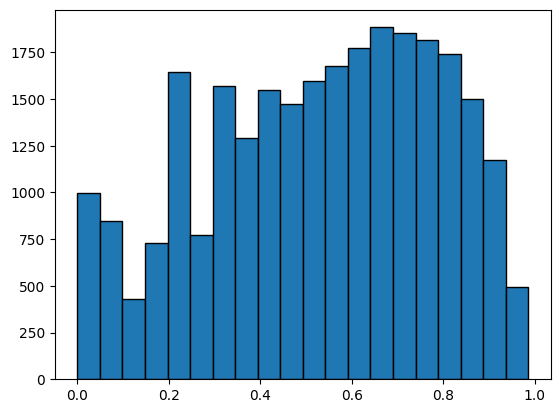

In [12]:
import numpy as np
from scipy.stats import norm

def wilson_score(pos, neg, confidence=0.95):
    """
    Compute the lower bound of the Wilson score confidence interval.
    
    Args:
        pos: number of positive ratings
        neg: number of negative ratings
        confidence: confidence level (default 95%)
    
    Returns:
        Wilson lower bound score in [0, 1]
    """
    n = pos + neg
    if n == 0:
        return 0.0
    
    p = pos / n
    z = norm.ppf((1 + confidence) / 2)  # z = 1.96 for 95%
    
    numerator   = p + z**2 / (2*n) - z * np.sqrt((p*(1-p) + z**2/(4*n)) / n)
    denominator = 1 + z**2 / n
    
    return numerator / denominator

def categorize_wilson(score):
    if score < 0.20:
        return 'Negative'
    elif score < 0.42:
        return 'Mostly Negative'
    elif score < 0.65:
        return 'Mixed'
    elif score < 0.8:
        return 'Mostly Positive'
    else:
        return 'Positive'

df['wilson_score'] = df.apply(lambda row: wilson_score(row['positive_ratings'], row['negative_ratings']), axis=1)
df['rating_category'] = df['wilson_score'].apply(categorize_wilson)
print(df['rating_category'].value_counts(normalize=True).round(3))
print(df['wilson_score'].describe())

plt.hist(df['wilson_score'], bins=20, edgecolor='black')

In [13]:
df.to_csv('steam_final_labelled.csv', index=False)

In [ ]:
# Testing

df3 = pd.read_csv('steam_final_labelled.csv')
df3.sample(5)

,Unnamed: 0.1,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,...,cleaned,processor_Ghz,RAM_mb,GPU_mb,internet_required,storage_mb,cpu_source,tier,wilson_score,rating_category
10666,19224,524650,DANGEROUS DUELS,2016-10-26,1,Sophie Houlden,Sophie Houlden,"['windows', 'mac', 'linux']",0,"['Multi-player', 'Local Multi-Player', 'Shared...",...,Minimum: OS: Windows XP SP2+ Processor: SSE2...,1.5,2048.0,NaN,0,NaN,inferred_from_model,Medium,0.551969,Mixed
11964,21545,560150,PLANNES,2016-12-08,1,"Tricol Co., Ltd.","Tricol Co., Ltd.",['windows'],0,"['Single-player', 'Online Multi-Player', 'Loca...",...,Minimum: Requires a 64-bit processor and opera...,3.3,8192.0,2048.0,0,2048.0,inferred_from_model,High,0.577654,Mixed
5985,9310,384630,Aviary Attorney,2015-12-21,1,Sketchy Logic,Sketchy Logic,"['windows', 'mac']",0,"['Single-player', 'Steam Trading Cards', 'Capt...",...,"Minimum: OS: Windows 7, 8, or 10 Memory: 2 G...",NaN,2048.0,NaN,0,500.0,unknown,High,0.936259,Positive
22524,44452,872550,Urbance Clans Card Battle!,2018-10-03,1,Steambot;Fishing Cactus,Plug In Digital,['windows'],0,['Single-player'],...,Minimum: OS: Microsoft Windows XP/Vista/7/8/8...,3.3,4096.0,1024.0,0,1024.0,inferred_from_model,Medium,0.510109,Mixed
18429,33895,752310,Flying Salvager,2017-12-08,1,Wonderbox Games,Wonderbox Games,"['windows', 'mac']",0,"['Single-player', 'Steam Achievements']",...,Minimum: OS: Windows XP / Vista / 7 / 8 / 10 ...,2.2,2048.0,512.0,0,500.0,measured,Medium,0.168180,Negative
